## How different model perferm on unseen data 

In [316]:
import numpy as np 
import pandas as pd 

from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import NearestNeighbors
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


In [317]:
df = pd.read_csv(r'D:\VS-code\experiment_aml\dataset\UCI_Credit_Card.csv')

In [318]:
df = df.rename(columns={"default.payment.next.month": "default"})
df = df[df["SEX"].isin([1, 2])]
df["EDUCATION"] = df["EDUCATION"].replace([0, 5, 6], 4)
df["MARRIAGE"] = df["MARRIAGE"].replace(0, 3)

In [319]:
df

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,1,3,1,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,3,2,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,2,2,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,3,1,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [320]:
X = df.drop(columns=["ID", "default"])
y = df["default"].values

In [321]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [322]:
X0 = X_scaled[y == 0]
X1 = X_scaled[y == 1]

n = min(len(X0), len(X1))

X0_bal = resample(X0, n_samples=n, random_state=42, replace=False)
X1_bal = resample(X1, n_samples=n, random_state=42, replace=False)

X_bal = np.vstack([X0_bal, X1_bal])
y_bal = np.array([0]*n + [1]*n)

In [323]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_bal)


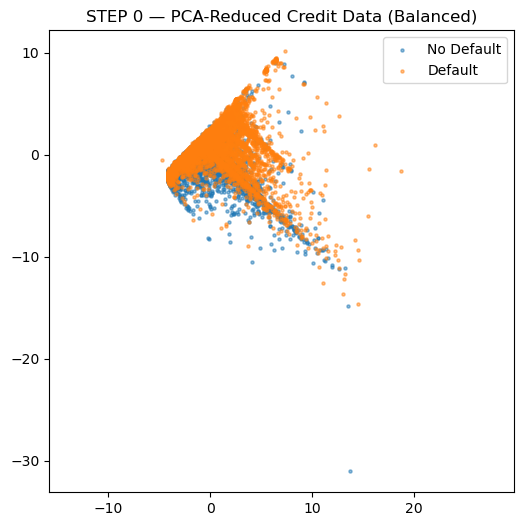

In [324]:
plt.figure(figsize=(6,6))
plt.scatter(X_2d[y_bal==0, 0], X_2d[y_bal==0, 1], s=5, alpha=0.5, label="No Default")
plt.scatter(X_2d[y_bal==1, 0], X_2d[y_bal==1, 1], s=5, alpha=0.5, label="Default")
plt.legend()
plt.axis("equal")
plt.title("STEP 0 — PCA-Reduced Credit Data (Balanced)")
plt.show()

In [325]:
X_train, X_test, y_train, y_test = train_test_split(X_2d, y_bal,test_size=0.3,random_state=42,stratify=y_bal)

In [326]:
x_min, x_max = -2.5, 2.5
y_min, y_max = -2.5, 2.5

In [327]:
def in_void(X):
    return ((X[:, 0] >= x_min) & (X[:, 0] <= x_max) &(X[:, 1] >= y_min) & (X[:, 1] <= y_max))


In [328]:
void = in_void(X_train)

X_train_void = X_train[~void]
y_train_void = y_train[~void]


In [329]:
mask = (X_train_void[:, 0] > -15) & (X_train_void[:, 1] > -15)

X_train_void = X_train_void[mask]
y_train_void = y_train_void[mask]

In [330]:
print("original training size:", len(X_train))
print("after void removal:", len(X_train_void))
print("points removed:", void.sum())


original training size: 9290
after void removal: 3892
points removed: 5397


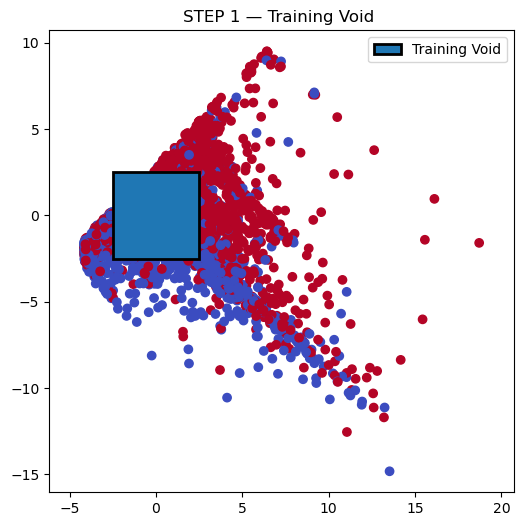

In [331]:
plt.figure(figsize=(6,6))

plt.scatter(X_train_void[:, 0], X_train_void[:, 1],c=y_train_void, cmap="coolwarm" )

plt.gca().add_patch(
    plt.Rectangle((x_min, y_min),x_max - x_min,y_max - y_min,edgecolor="black",linewidth=2,label="Training Void"))

plt.title("STEP 1 — Training Void ")
plt.axis("equal")
plt.legend()
plt.show()


In [332]:
lr = LogisticRegression()
lr.fit(X_train_void, y_train_void)

lr_pred = lr.predict(X_test)
lr_conf = lr.predict_proba(X_test).max(axis=1)

In [333]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_void, y_train_void)

dt_pred = dt.predict(X_test)
dt_conf = dt.predict_proba(X_test).max(axis=1)

In [334]:
knn = KNeighborsClassifier()
knn.fit(X_train_void, y_train_void)

knn_pred = knn.predict(X_test)
knn_conf = knn.predict_proba(X_test).max(axis=1)

In [335]:

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_void, y_train_void)

rf_pred = rf.predict(X_test)
rf_conf = rf.predict_proba(X_test).max(axis=1)

In [336]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_void, y_train_void)

gb_pred = gb.predict(X_test)
gb_conf = gb.predict_proba(X_test).max(axis=1)

In [337]:
xg = XGBClassifier(n_estimators=100,random_state=42)
xg.fit(X_train_void, y_train_void)

xg_pred = xg.predict(X_test)
xg_conf = xg.predict_proba(X_test).max(axis=1)  

In [338]:
models = {"Logistic Regression": (lr_pred, lr_conf),"Decision Tree": (dt_pred, dt_conf),"KNN": (knn_pred, knn_conf),
    "Random Forest": (rf_pred, rf_conf),"Gradient Boosting": (gb_pred, gb_conf), "XGBoost": (xg_pred, xg_conf)}

In [339]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

In [340]:
region_labels = []

for x in X_test:
    if (x_min <= x[0] <= x_max) and (y_min <= x[1] <= y_max):
        region_labels.append("Interpolation")
    else:
        region_labels.append("ID")  
        
region_labels = np.array(region_labels)


In [341]:
results = {}

for model_name, (y_pred, y_conf) in models.items():
    
    results[model_name] = {}
    
    for region in ["ID", "Interpolation"]:
        mask = region_labels == region
        
        
        acc = accuracy(y_test[mask], y_pred[mask])
        mean_conf = y_conf[mask].mean()
        
        results[model_name][region] = {"accuracy": acc,"mean_confidence": mean_conf,"n_samples": mask.sum()}


In [342]:
for model, region_data in results.items():
    print(f"\nModel: {model}")
    for region, stats in region_data.items():
        print( f"  {region:14s} | "f"accuracy: {stats['accuracy']:.3f} | "f"mean Conf: {stats['mean_confidence']:.3f} | "f"N: {stats['n_samples']}")



Model: Logistic Regression
  ID             | accuracy: 0.668 | mean Conf: 0.673 | N: 1638
  Interpolation  | accuracy: 0.480 | mean Conf: 0.642 | N: 2344

Model: Decision Tree
  ID             | accuracy: 0.653 | mean Conf: 1.000 | N: 1638
  Interpolation  | accuracy: 0.515 | mean Conf: 1.000 | N: 2344

Model: KNN
  ID             | accuracy: 0.707 | mean Conf: 0.782 | N: 1638
  Interpolation  | accuracy: 0.558 | mean Conf: 0.851 | N: 2344

Model: Random Forest
  ID             | accuracy: 0.696 | mean Conf: 0.786 | N: 1638
  Interpolation  | accuracy: 0.551 | mean Conf: 0.741 | N: 2344

Model: Gradient Boosting
  ID             | accuracy: 0.723 | mean Conf: 0.706 | N: 1638
  Interpolation  | accuracy: 0.549 | mean Conf: 0.693 | N: 2344

Model: XGBoost
  ID             | accuracy: 0.686 | mean Conf: 0.763 | N: 1638
  Interpolation  | accuracy: 0.537 | mean Conf: 0.790 | N: 2344


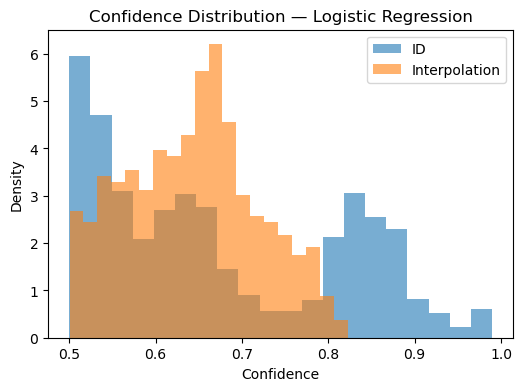

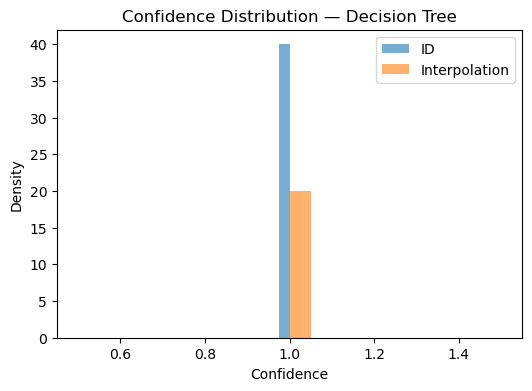

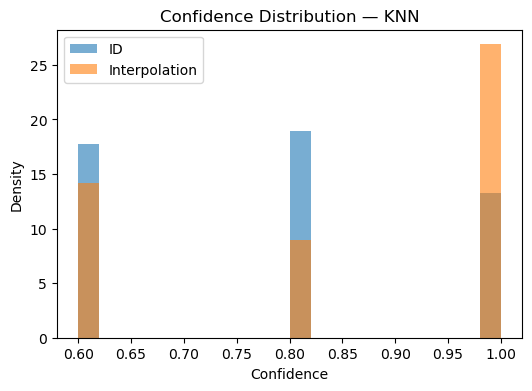

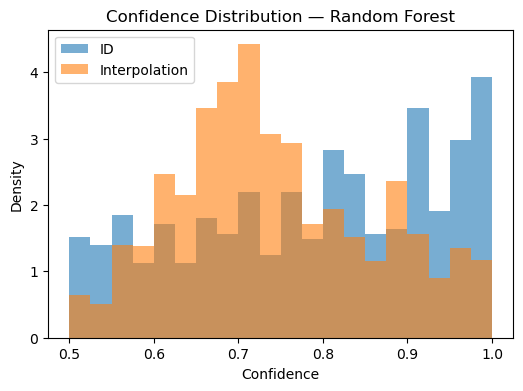

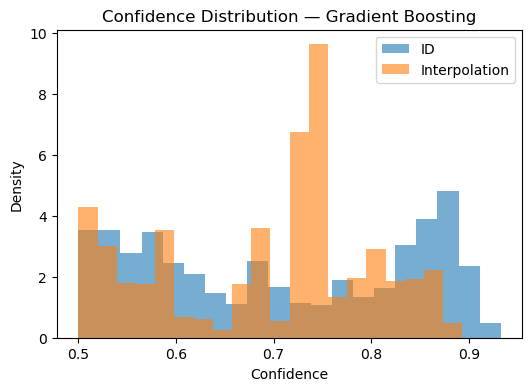

In [115]:
for model_name, (y_pred, y_conf) in models.items():
    
    plt.figure(figsize=(6,4))
    
    for region in ["ID", "Interpolation"]:
        mask = region_labels == region

        plt.hist(
            y_conf[mask],bins=20,alpha=0.6,label=region,density=True)
    
    plt.title(f"Confidence Distribution — {model_name}")
    plt.xlabel("Confidence")
    plt.ylabel("Density")
    plt.legend()
    plt.show()


In [116]:
nn = NearestNeighbors(n_neighbors=1)
nn.fit(X_train_void)

distances, _ = nn.kneighbors(X_test)
distances = distances.flatten()

In [117]:
n_bins = 10
bins = np.linspace(distances.min(), distances.max(), n_bins + 1)
bin_ids = np.digitize(distances, bins) - 1


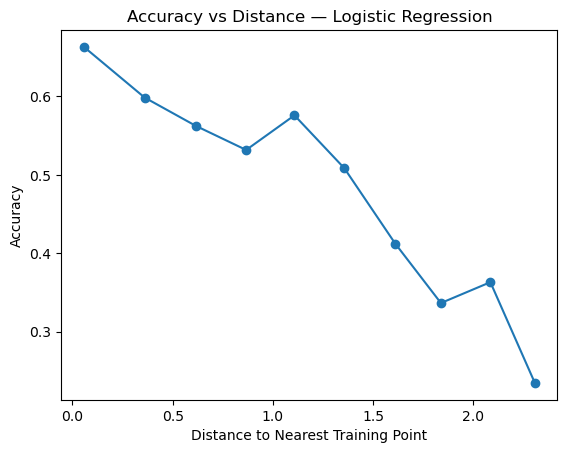

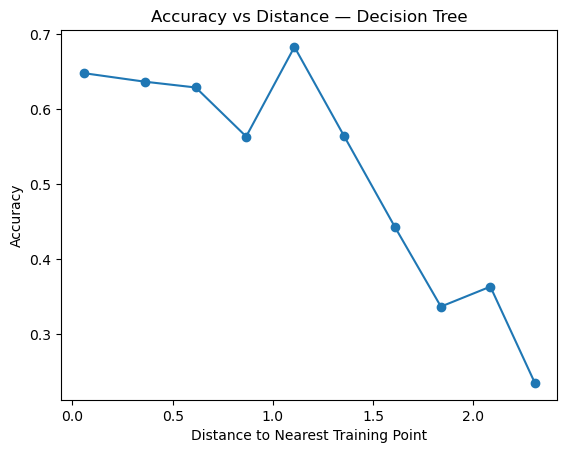

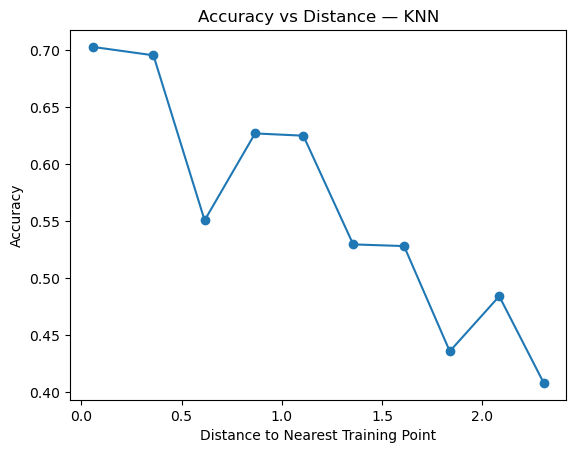

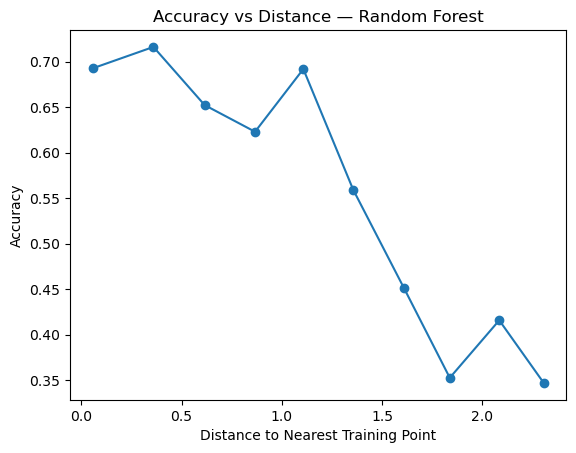

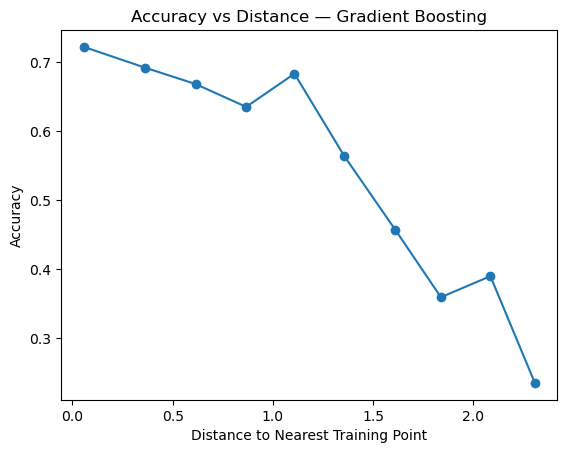

In [118]:
for model_name, (y_pred, y_conf) in models.items():
    
    acc_per_bin = []
    bin_centers = []
    
    for b in range(n_bins):
        mask = bin_ids == b        
        
        acc = np.mean(y_pred[mask] == y_test[mask])
        acc_per_bin.append(acc)
        bin_centers.append(distances[mask].mean())

    plt.figure()
    plt.plot(bin_centers, acc_per_bin, marker='o')
    plt.xlabel("Distance to Nearest Training Point")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy vs Distance — {model_name}")
    plt.show()



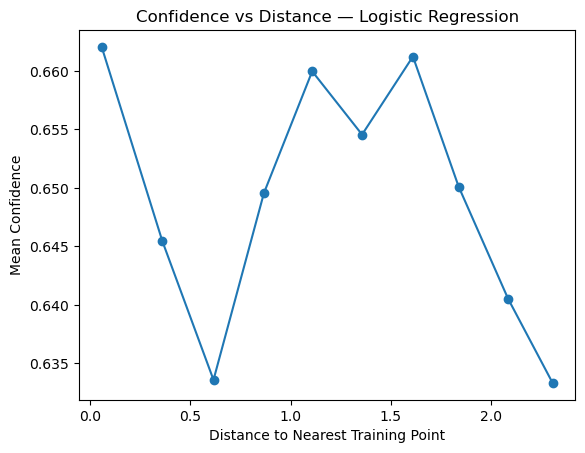

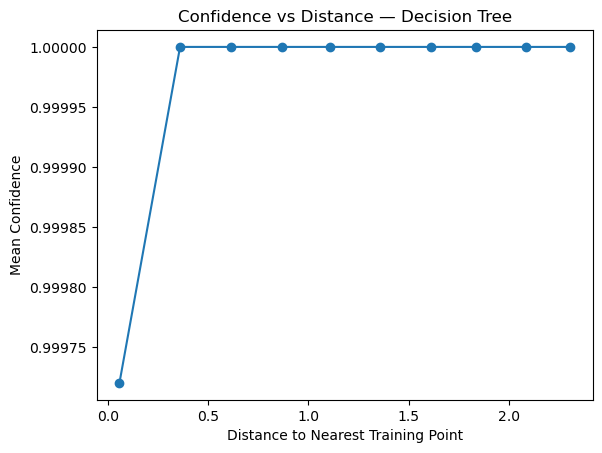

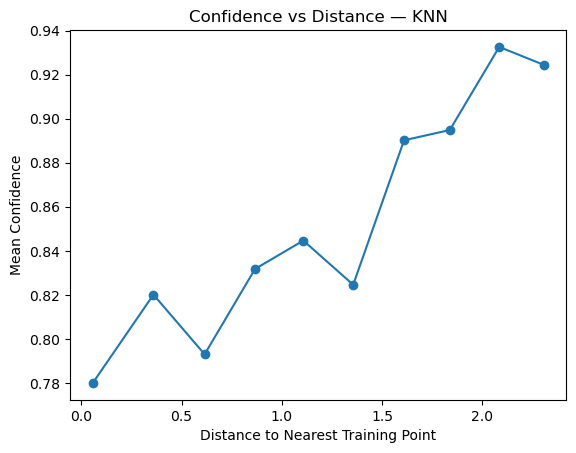

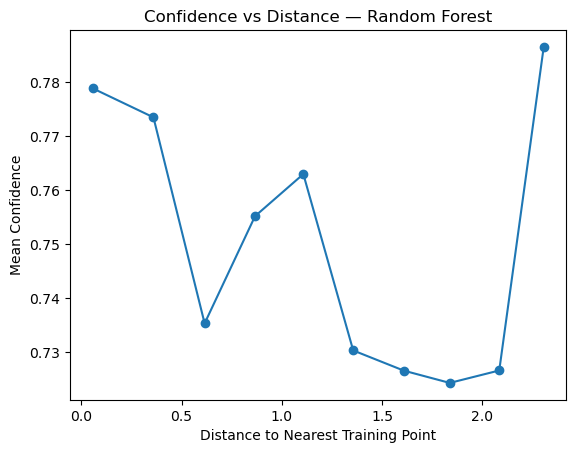

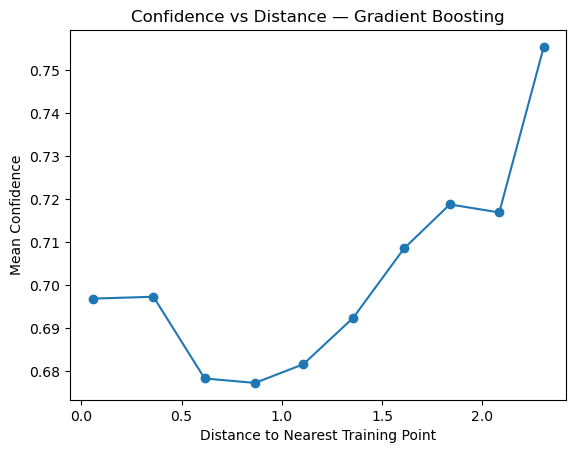

In [119]:
for model_name, (y_pred, y_conf) in models.items():
    
    conf_per_bin = []
    bin_centers = []
    
    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() == 0:
            continue
        
        conf = y_conf[mask].mean()
        conf_per_bin.append(conf)
        bin_centers.append(distances[mask].mean())
    
    plt.figure()
    plt.plot(bin_centers, conf_per_bin, marker='o')
    plt.xlabel("Distance to Nearest Training Point")
    plt.ylabel("Mean Confidence")
    plt.title(f"Confidence vs Distance — {model_name}")
    plt.show()


#### Model is confidently wrong in regions it never seen.

c:\Users\rudra\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\rudra\anaconda3\Lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


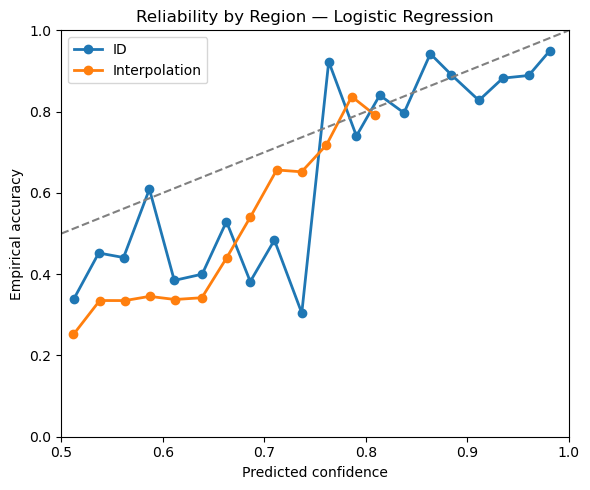

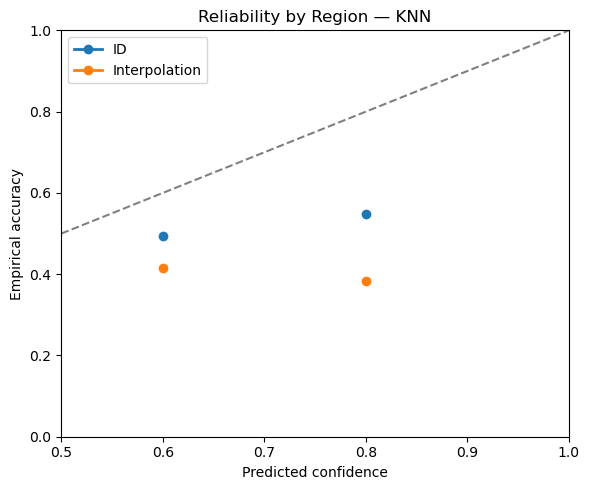

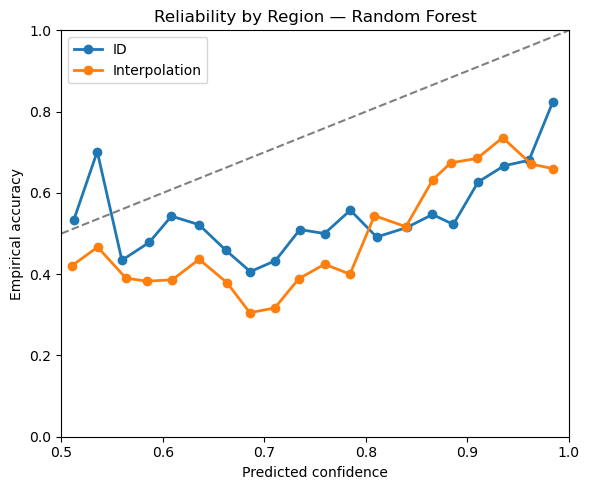

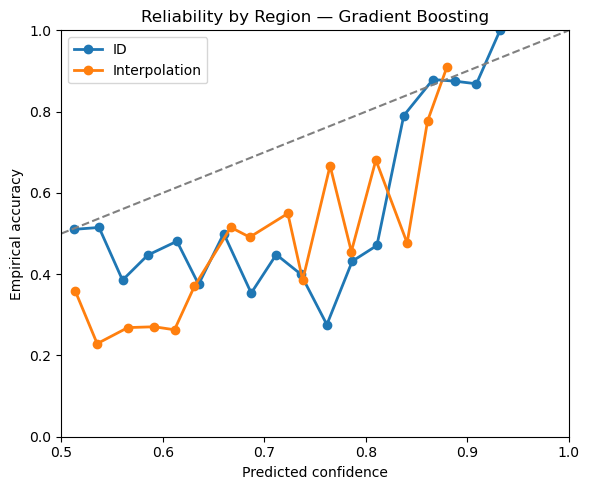

In [120]:
n_conf_bins = 20  

for model_name, (y_pred, y_conf) in models.items():
    
    if model_name == "Decision Tree":
        continue
    
    plt.figure(figsize=(6,5))
    for region in ["ID", "Interpolation"]:
        mask = region_labels == region
      
        conf_bins = np.linspace(0.5, 1.0, n_conf_bins + 1)
        bin_ids = np.digitize(y_conf[mask], conf_bins) - 1
        
        empirical = []
        predicted = []
        
        for b in range(n_conf_bins):
            m = bin_ids == b
            
            empirical.append(np.mean(y_test[mask][m]))
            predicted.append(np.mean(y_conf[mask][m]))
        
        plt.plot(predicted,empirical,marker='o',linewidth=2,label=region)
    
    plt.plot([0.5, 1.0], [0.5, 1.0], '--', color='gray')
    
    plt.xlim(0.5, 1.0)
    plt.ylim(0.0, 1.0)
    
    plt.xlabel("Predicted confidence")
    plt.ylabel("Empirical accuracy")
    plt.title(f"Reliability by Region — {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()


chake 60 % probability = 60 time it will be true . 

 exp for a baised coin the probability (have 2 output t or f ) if probability of t is 60 we are expeting f = 40 

prediction of a model have 2 output ( true or fulse ) if the probability of n number of rows are 60 % , we should expect 60 % is true and 40 is wrong .

In [121]:
from scipy.stats import spearmanr

summary = {}

In [122]:
for model_name, (y_pred, y_conf) in models.items():
    
    correctness = (y_pred == y_test).astype(int)
    
    acc_corr, _ = spearmanr(distances, correctness)
    conf_corr, _ = spearmanr(distances, y_conf)
    
    summary[model_name] = {"accuracy_vs_distance": acc_corr,"confidence_vs_distance": conf_corr}

In [123]:
print("Model-wise Distance Sensitivity\n")

for model, stats in summary.items():
    print(f"{model:18s} | "
        f"accuracy vs dist: {stats['accuracy_vs_distance']:.3f} | "
        f"confidence vs dist: {stats['confidence_vs_distance']:.3f}")


Model-wise Distance Sensitivity

Logistic Regression | accuracy vs dist: -0.202 | confidence vs dist: 0.112
Decision Tree      | accuracy vs dist: -0.176 | confidence vs dist: 0.027
KNN                | accuracy vs dist: -0.159 | confidence vs dist: 0.312
Random Forest      | accuracy vs dist: -0.188 | confidence vs dist: -0.109
Gradient Boosting  | accuracy vs dist: -0.223 | confidence vs dist: 0.112


## Separating cluster

In [183]:
X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal,test_size=0.3,random_state=42,stratify=y_bal)

#### Separate the full_data into cluster

In [220]:
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters,random_state=42)

train_clusters = kmeans.fit_predict(X_train)
test_clusters = kmeans.predict(X_test)

##### Removeing a full cluster from training

In [231]:
removed_cluster = 2

void = (train_clusters == removed_cluster)

X_train_void = X_train[~void]
y_train_void = y_train[~void]

print("original training size:", len(X_train))
print("after cluster removal:", len(X_train_void))
print("points removed:", void.sum())

original training size: 9290
after cluster removal: 6084
points removed: 3206


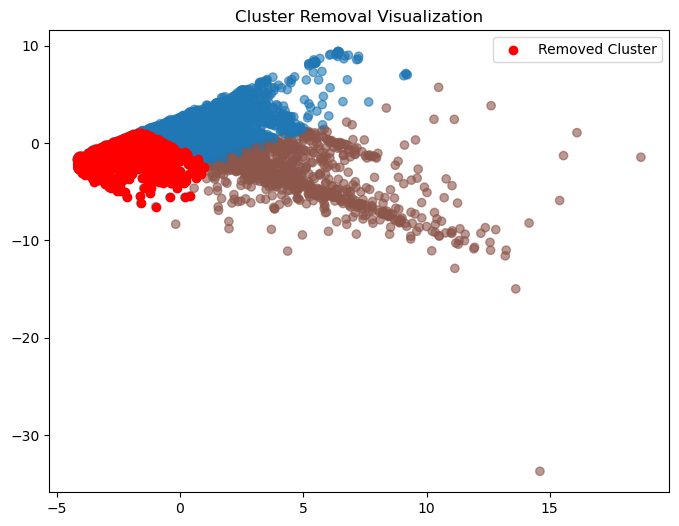

In [232]:
pca = PCA(n_components=2)

X_vis = pca.fit_transform(X_train)

plt.figure(figsize=(8,6))

plt.scatter(X_vis[:,0],X_vis[:,1],c=train_clusters,cmap='tab10',alpha=0.6)

removed_mask = train_clusters == removed_cluster

plt.scatter(
    X_vis[removed_mask,0],
    X_vis[removed_mask,1],
    color='red',
    label='Removed Cluster'
)

plt.legend()
plt.title("Cluster Removal Visualization")

plt.show()

### Model Train 

In [233]:
model_objs = {"Logistic Regression": LogisticRegression(C=0.1,max_iter=1000),
    
    "Decision Tree": DecisionTreeClassifier(max_depth=5, min_samples_split=15, min_samples_leaf=10, random_state=42),
        
    "KNN": KNeighborsClassifier(n_neighbors=15, weights='distance',metric='manhattan'),
    
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=12,min_samples_split=15,
                                             min_samples_leaf=5,random_state=42),
    
    "Gradient Boosting": GradientBoostingClassifier( n_estimators=100, learning_rate=0.05,max_depth=5,
                                                     subsample=0.8,random_state=42),
    
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, subsample=0.8,
                             colsample_bytree=0.8,gamma=2,random_state=42),
    
    "LightGBM": LGBMClassifier(n_estimators=200, num_leaves=31,learning_rate=0.05,max_depth=5, 
        min_child_samples=20, subsample=0.8,random_state=42, verbose=-1)
}


models = {}

for name , hyperparams in model_objs.items():
    model = hyperparams
    model.fit(X_train_void, y_train_void)
    
    name_pred = model.predict(X_test)

    models[f"{name}"] = (model.predict(X_test),model.predict_proba(X_test).max(axis=1),model.predict_proba(X_test)[:, 1])


c:\Users\rudra\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\rudra\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\rudra\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\rudra\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [234]:
region_labels = []

for c in test_clusters:
    
    if c == removed_cluster:
        region_labels.append("Interpolation")
    else:
        region_labels.append("ID")

region_labels = np.array(region_labels)

In [235]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

results = {}

for model_name, (y_pred, y_conf, y_prob) in models.items():

    results[model_name] = {}

    for region in ["ID", "Interpolation"]:

        mask = region_labels == region

        acc = accuracy(y_test[mask], y_pred[mask])

        mean_conf = y_conf[mask].mean()

        results[model_name][region] = {
            "accuracy": acc,
            "mean_confidence": mean_conf,
            "n_samples": mask.sum()
        }

In [236]:
for model, region_data in results.items():

    print(f"\nModel: {model}")

    for region, stats in region_data.items():

        print(
            f"  {region:14s} | "
            f"accuracy: {stats['accuracy']:.3f} | "
            f"mean Conf: {stats['mean_confidence']:.3f} | "
            f"N: {stats['n_samples']}"
        )


Model: Logistic Regression
  ID             | accuracy: 0.725 | mean Conf: 0.704 | N: 2614
  Interpolation  | accuracy: 0.607 | mean Conf: 0.853 | N: 1368

Model: Decision Tree
  ID             | accuracy: 0.727 | mean Conf: 0.745 | N: 2614
  Interpolation  | accuracy: 0.610 | mean Conf: 0.708 | N: 1368

Model: KNN
  ID             | accuracy: 0.721 | mean Conf: 0.741 | N: 2614
  Interpolation  | accuracy: 0.581 | mean Conf: 0.652 | N: 1368

Model: Random Forest
  ID             | accuracy: 0.737 | mean Conf: 0.725 | N: 2614
  Interpolation  | accuracy: 0.615 | mean Conf: 0.622 | N: 1368

Model: Gradient Boosting
  ID             | accuracy: 0.740 | mean Conf: 0.738 | N: 2614
  Interpolation  | accuracy: 0.632 | mean Conf: 0.677 | N: 1368

Model: XGBoost
  ID             | accuracy: 0.738 | mean Conf: 0.748 | N: 2614
  Interpolation  | accuracy: 0.615 | mean Conf: 0.678 | N: 1368

Model: LightGBM
  ID             | accuracy: 0.739 | mean Conf: 0.748 | N: 2614
  Interpolation  | accura

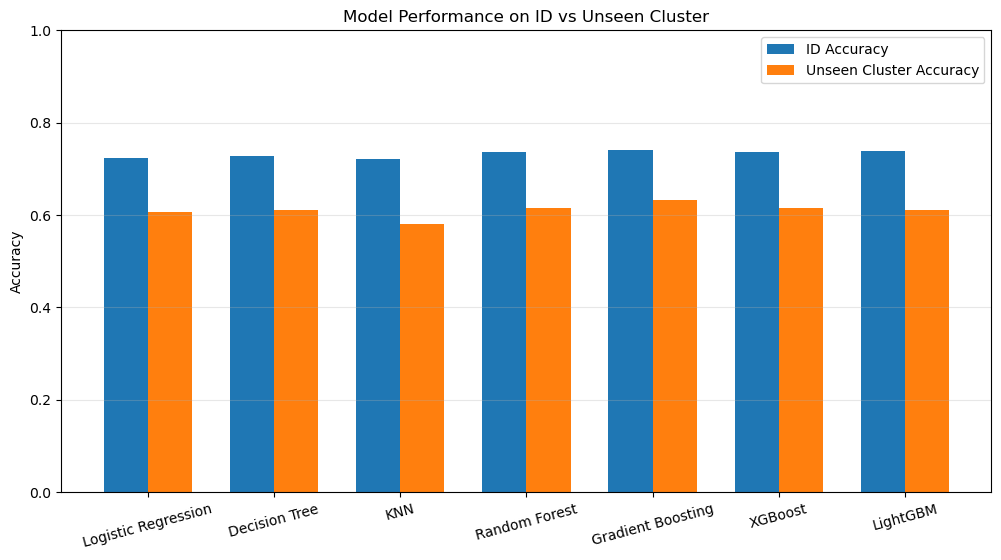

In [237]:
results[model][region]["accuracy"]
results[model][region]["mean_confidence"]


models_list = list(results.keys())

id_acc = [results[m]["ID"]["accuracy"]for m in models_list]

interp_acc = [results[m]["Interpolation"]["accuracy"]for m in models_list]

x = np.arange(len(models_list))
width = 0.35

plt.figure(figsize=(12,6))
plt.bar(x - width/2,id_acc,width,label="ID Accuracy")
plt.bar(x + width/2,interp_acc,width,label="Unseen Cluster Accuracy")
plt.xticks(x, models_list, rotation=15)
plt.ylabel("Accuracy")
plt.title("Model Performance on ID vs Unseen Cluster")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

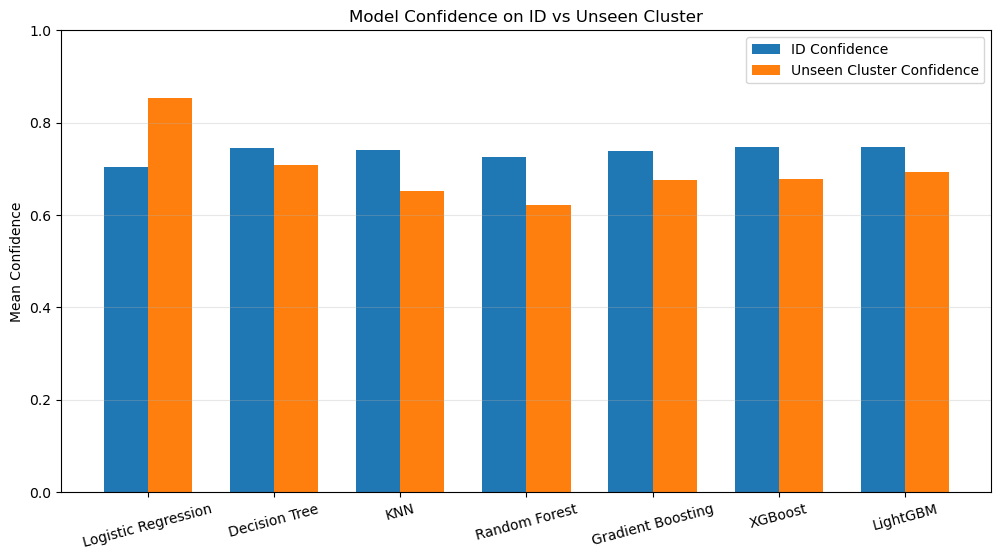

In [238]:
id_conf = [results[m]["ID"]["mean_confidence"]for m in models_list]

interp_conf = [results[m]["Interpolation"]["mean_confidence"]for m in models_list]

plt.figure(figsize=(12,6))
plt.bar(x - width/2,id_conf,width,label="ID Confidence")
plt.bar(x + width/2,interp_conf,width,label="Unseen Cluster Confidence")
plt.xticks(x, models_list, rotation=15)
plt.ylabel("Mean Confidence")
plt.title("Model Confidence on ID vs Unseen Cluster")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

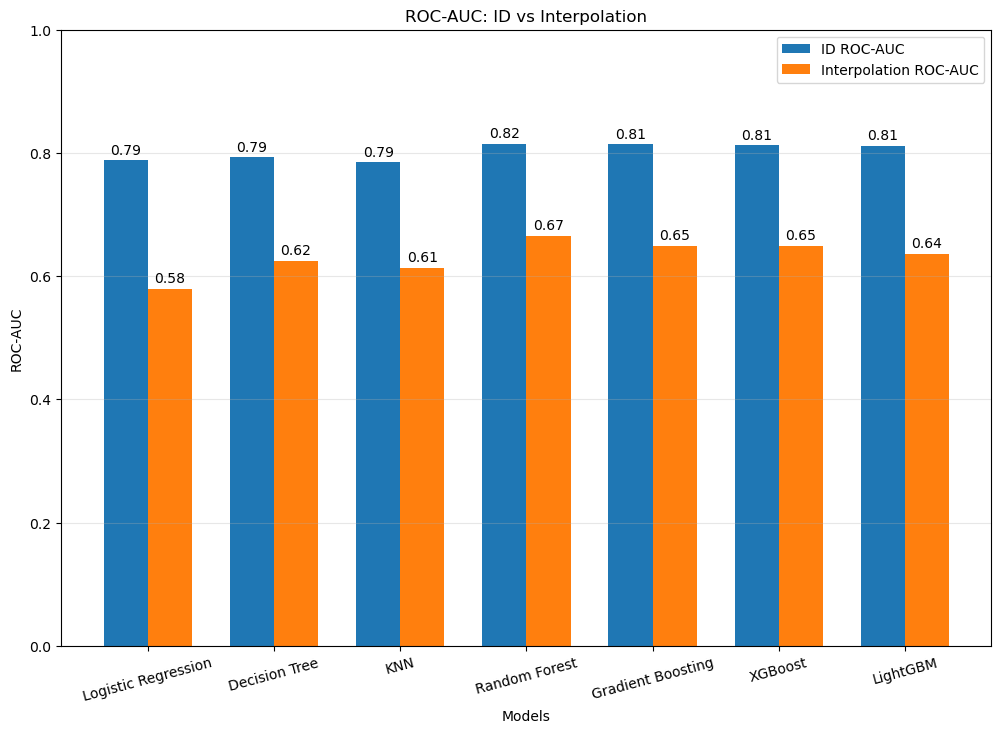

In [239]:
from sklearn.metrics import roc_auc_score

id_mask = np.array(region_labels == "ID")

interp_mask = np.array(region_labels == "Interpolation")
roc_results = {}

for model_name, outputs in models.items():
    y_pred, y_conf, y_prob = outputs

    y_prob = np.array(y_prob)
    id_auc = roc_auc_score(y_test[id_mask],y_prob[id_mask])

    interp_auc = roc_auc_score(y_test[interp_mask],y_prob[interp_mask])

    roc_results[model_name] = {"ID": id_auc,"Interpolation": interp_auc}

models_list = list(roc_results.keys())

id_scores = [roc_results[m]["ID"]for m in models_list]

interp_scores = [roc_results[m]["Interpolation"]for m in models_list]

x = np.arange(len(models_list))

width = 0.35

plt.figure(figsize=(12,8))

bars1 = plt.bar(x - width/2,id_scores,width,label="ID ROC-AUC")

bars2 = plt.bar(x + width/2,interp_scores,width,label="Interpolation ROC-AUC")
plt.xticks(x,models_list,rotation=15)
plt.ylabel("ROC-AUC")
plt.xlabel("Models")
plt.title("ROC-AUC: ID vs Interpolation")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', alpha=0.3)
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,height + 0.01,f"{height:.2f}",ha='center')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,height + 0.01,f"{height:.2f}",ha='center')

plt.show()

In [240]:
gap_id = []
gap_interp = []

for m in models_list:

    id_gap = (results[m]["ID"]["mean_confidence"]- results[m]["ID"]["accuracy"])

    interp_gap = (results[m]["Interpolation"]["mean_confidence"]- results[m]["Interpolation"]["accuracy"])

    gap_id.append(id_gap)
    gap_interp.append(interp_gap)

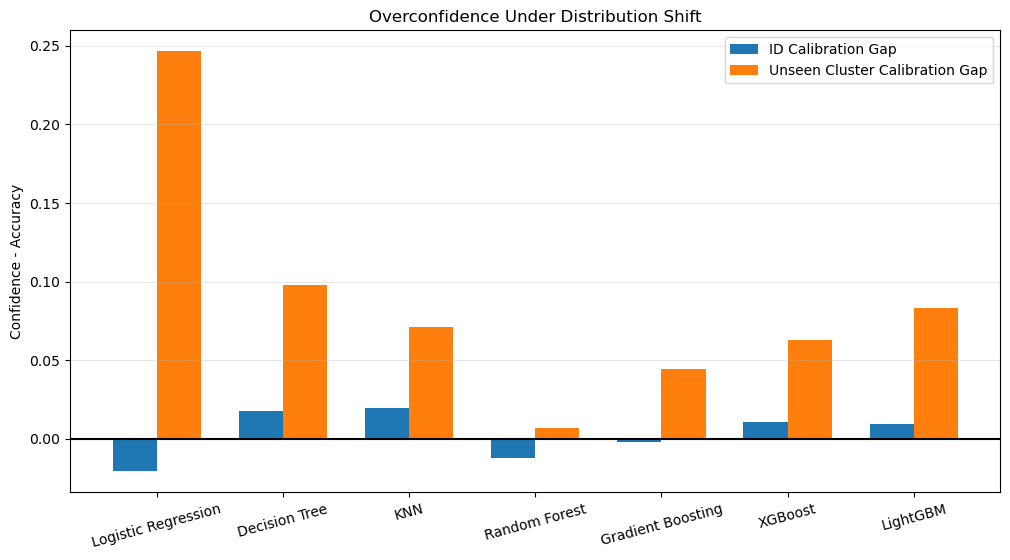

In [241]:
plt.figure(figsize=(12,6))
plt.bar(x - width/2,gap_id,width,label="ID Calibration Gap")
plt.bar(x + width/2,gap_interp,width,label="Unseen Cluster Calibration Gap")
plt.axhline(0, color='black')
plt.xticks(x, models_list, rotation=15)
plt.ylabel("Confidence - Accuracy")
plt.title("Overconfidence Under Distribution Shift")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

### Creating a void region around the most important features 

In [242]:
rf_base = RandomForestClassifier(n_estimators=200,random_state=42)
rf_base.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [244]:
feature_importance = pd.DataFrame({"feature": X.columns, "importance": rf_base.feature_importances_})

feature_importance = feature_importance.sort_values(by="importance", ascending=False)

print("Top 10 Features for Credit Default Prediction:")
print(feature_importance.head(10))

Top 10 Features for Credit Default Prediction:
      feature  importance
5       PAY_0    0.098730
4         AGE    0.063562
0   LIMIT_BAL    0.061914
11  BILL_AMT1    0.061308
12  BILL_AMT2    0.054394
18   PAY_AMT2    0.053094
17   PAY_AMT1    0.052557
13  BILL_AMT3    0.050725
14  BILL_AMT4    0.049459
15  BILL_AMT5    0.049390


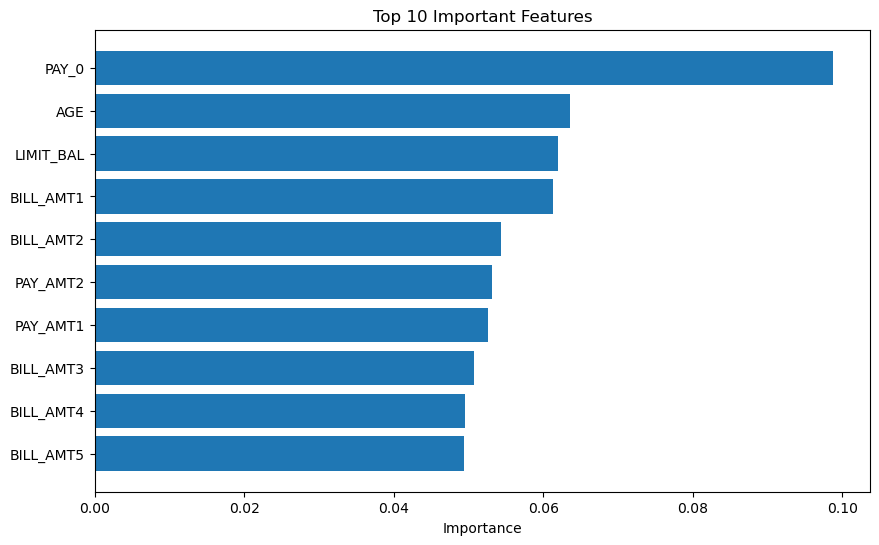

In [245]:
plt.figure(figsize=(10,6))

plt.barh(feature_importance["feature"][:10][::-1],feature_importance["importance"][:10][::-1])
plt.xlabel("Importance")
plt.title("Top 10 Important Features")
plt.show()

In [278]:
top_features = feature_importance["feature"].head(3).tolist()
feature_names = X.columns.tolist()
top_feature_idx = [feature_names.index(f)for f in top_features]
print(top_feature_idx)

[5, 4, 0]


In [300]:
X_train_df = pd.DataFrame(X_train,columns=feature_names)

percentile_ranges = {}

for feature in top_features:
    low = X_train_df[feature].quantile(0.45)
    high = X_train_df[feature].quantile(0.55)
    percentile_ranges[feature] = (low, high)
    print(f"{feature}: {low:.3f} to {high:.3f}")

PAY_0: 0.015 to 0.015
AGE: -0.270 to -0.053
LIMIT_BAL: -0.520 to -0.212


In [301]:
remove_mask = np.zeros(len(X_train_df), dtype=bool)

for feature in top_features:

    low, high = percentile_ranges[feature]

    feature_mask = (
        (X_train_df[feature] >= low) &
        (X_train_df[feature] <= high)
    )

    remove_mask |= feature_mask

In [302]:
X_train_void_df = X_train_df[~remove_mask]
y_train_void = y_train[~remove_mask]

X_train_void = X_train_void_df.values

In [303]:
print("Original training size:", len(X_train_df))

print("After removal:", len(X_train_void_df))

print("Rows removed:", remove_mask.sum())

Original training size: 9290
After removal: 4214
Rows removed: 5076


In [304]:
X_test_df = pd.DataFrame(X_test,columns=feature_names)
interp_mask = np.zeros(len(X_test_df), dtype=bool)
for feature in top_features:
    low, high = percentile_ranges[feature]
    feature_mask = (
        (X_test_df[feature] >= low) &
        (X_test_df[feature] <= high))
    interp_mask |= feature_mask

region_labels = np.where(interp_mask,"Interpolation","ID")

In [ ]:
model_objs = {"Logistic Regression": LogisticRegression(C=0.1,max_iter=1000),
    
    "Decision Tree": DecisionTreeClassifier(max_depth=5, min_samples_split=15, min_samples_leaf=10, random_state=42),
        
    "KNN": KNeighborsClassifier(n_neighbors=15, weights='distance',metric='manhattan'),
    
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=12,min_samples_split=15,
                                             min_samples_leaf=5,random_state=42),
    
    "Gradient Boosting": GradientBoostingClassifier( n_estimators=100, learning_rate=0.05,max_depth=5,
                                                     subsample=0.8,random_state=42),
    
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, subsample=0.8,
                             colsample_bytree=0.8,gamma=2,random_state=42),
    
    "LightGBM": LGBMClassifier(n_estimators=200, num_leaves=31,learning_rate=0.05,max_depth=5, 
        min_child_samples=20, subsample=0.8,random_state=42, verbose=-1)
}


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score

X_test_df = pd.DataFrame(X_test, columns=feature_names)
interp_mask = np.zeros(len(X_test_df), dtype=bool)

for feature in top_features:
    low, high = percentile_ranges[feature]
    feature_mask = (X_test_df[feature] >= low) & (X_test_df[feature] <= high)
    interp_mask |= feature_mask

region_labels = np.where(interp_mask, "Interpolation", "ID")

models_data = {}
for name, hyperparams in model_objs.items():
    model = hyperparams
    model.fit(X_train_void, y_train_void)
    y_pred = model.predict(X_test_df)
    y_conf = model.predict_proba(X_test_df).max(axis=1)
    y_prob = model.predict_proba(X_test_df)[:, 1]
    models_data[name] = (y_pred, y_conf, y_prob)

results = {}
for model_name, (y_pred, y_conf, y_prob) in models_data.items():
    results[model_name] = {}
    for region in ["ID", "Interpolation"]:
        mask = region_labels == region
        if mask.sum() > 0:
            acc = accuracy_score(y_test[mask], y_pred[mask])
            mean_conf = y_conf[mask].mean()
            results[model_name][region] = {
                "accuracy": acc,
                "mean_confidence": mean_conf,
                "n_samples": mask.sum()
            }


In [309]:

for model, region_data in results.items():
    print(f"\nModel: {model}")
    for region, stats in region_data.items():
        print(f"  {region:14s} | accuracy: {stats['accuracy']:.3f} | mean Conf: {stats['mean_confidence']:.3f} | N: {stats['n_samples']}")


Model: Logistic Regression
  ID             | accuracy: 0.711 | mean Conf: 0.724 | N: 1800
  Interpolation  | accuracy: 0.473 | mean Conf: 0.662 | N: 2182

Model: Decision Tree
  ID             | accuracy: 0.709 | mean Conf: 0.739 | N: 1800
  Interpolation  | accuracy: 0.670 | mean Conf: 0.693 | N: 2182

Model: KNN
  ID             | accuracy: 0.714 | mean Conf: 0.737 | N: 1800
  Interpolation  | accuracy: 0.467 | mean Conf: 0.745 | N: 2182

Model: Random Forest
  ID             | accuracy: 0.733 | mean Conf: 0.720 | N: 1800
  Interpolation  | accuracy: 0.596 | mean Conf: 0.631 | N: 2182

Model: Gradient Boosting
  ID             | accuracy: 0.739 | mean Conf: 0.735 | N: 1800
  Interpolation  | accuracy: 0.659 | mean Conf: 0.651 | N: 2182

Model: XGBoost
  ID             | accuracy: 0.737 | mean Conf: 0.743 | N: 1800
  Interpolation  | accuracy: 0.642 | mean Conf: 0.660 | N: 2182

Model: LightGBM
  ID             | accuracy: 0.743 | mean Conf: 0.744 | N: 1800
  Interpolation  | accura

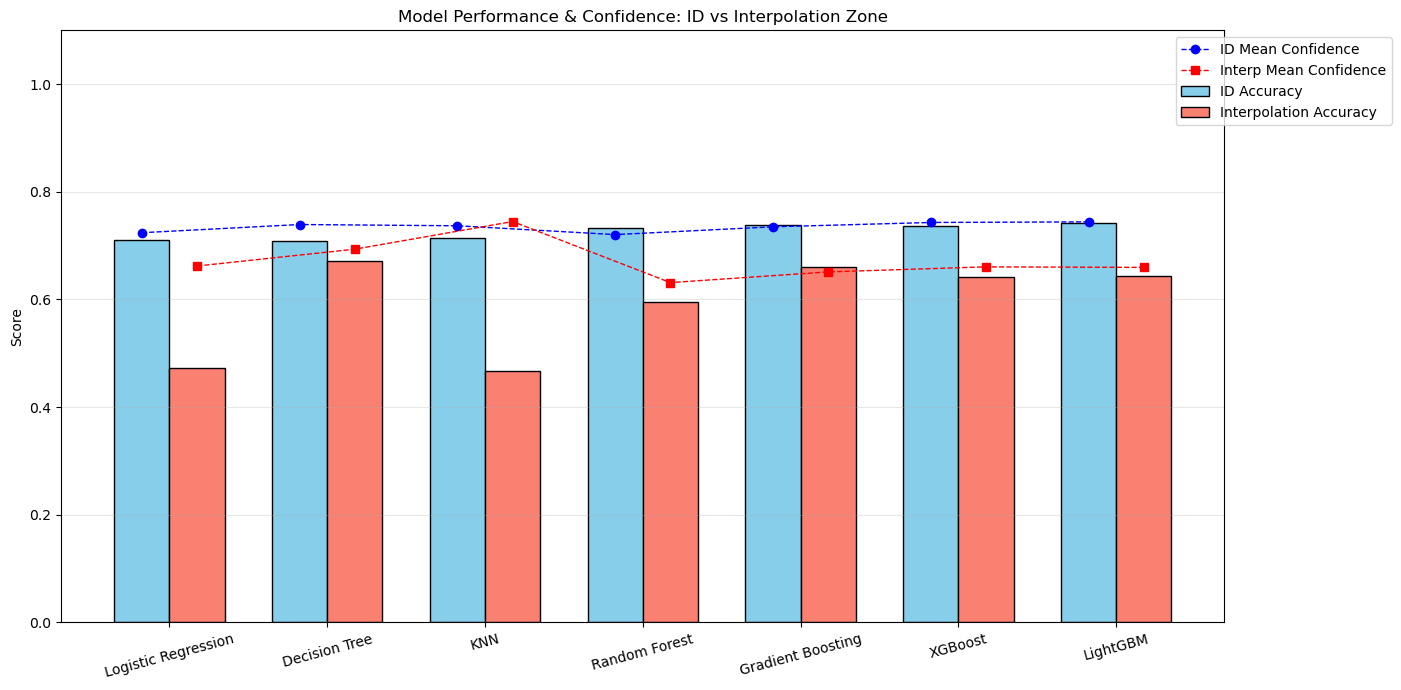

In [311]:
models_list = list(results.keys())

id_acc = [results[m]["ID"]["accuracy"] for m in models_list]
interp_acc = [results[m]["Interpolation"]["accuracy"] for m in models_list]
id_conf = [results[m]["ID"]["mean_confidence"] for m in models_list]
interp_conf = [results[m]["Interpolation"]["mean_confidence"] for m in models_list]

x = np.arange(len(models_list))
width = 0.35

plt.figure(figsize=(14, 7))

plt.bar(x - width/2, id_acc, width, label="ID Accuracy", color='skyblue', edgecolor='black')
plt.bar(x + width/2, interp_acc, width, label="Interpolation Accuracy", color='salmon', edgecolor='black')

plt.plot(x - width/2, id_conf, color='blue', marker='o', linestyle='dashed', linewidth=1, label='ID Mean Confidence')
plt.plot(x + width/2, interp_conf, color='red', marker='s', linestyle='dashed', linewidth=1, label='Interp Mean Confidence')

plt.xticks(x, models_list, rotation=15)
plt.ylabel("Score")
plt.title("Model Performance & Confidence: ID vs Interpolation Zone")
plt.ylim(0, 1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

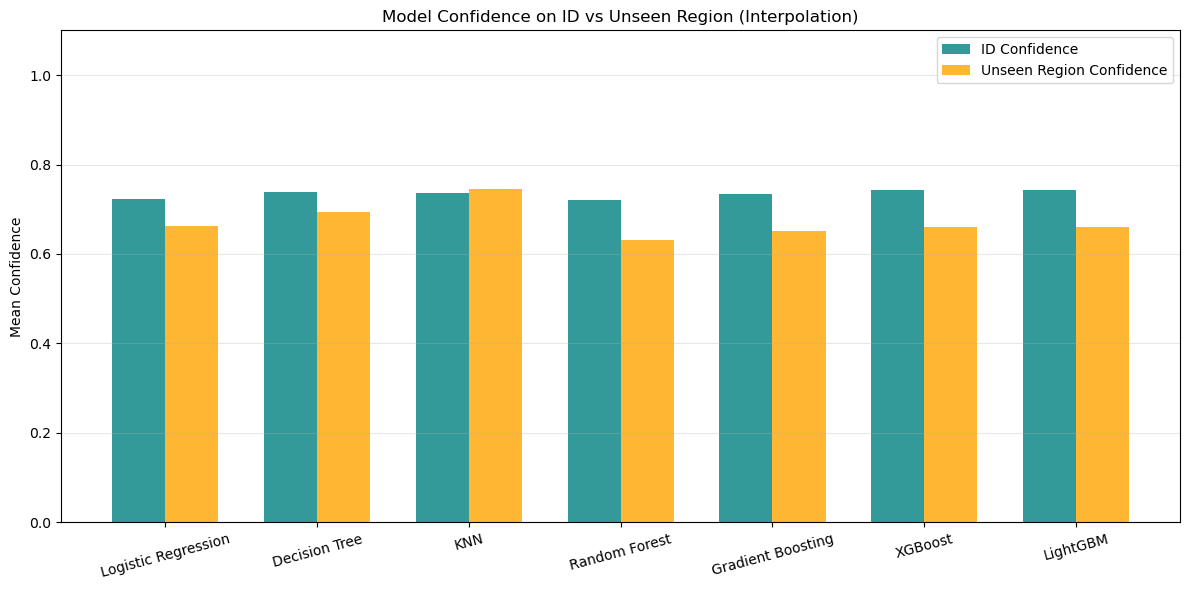

In [313]:
import matplotlib.pyplot as plt
import numpy as np

models_list = list(results.keys())

id_conf = [results[m]["ID"]["mean_confidence"] for m in models_list]
interp_conf = [results[m]["Interpolation"]["mean_confidence"] for m in models_list]

x = np.arange(len(models_list))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, id_conf, width, label="ID Confidence", color='teal', alpha=0.8)
plt.bar(x + width/2, interp_conf, width, label="Unseen Region Confidence", color='orange', alpha=0.8)

plt.xticks(x, models_list, rotation=15)
plt.ylabel("Mean Confidence")
plt.title("Model Confidence on ID vs Unseen Region (Interpolation)")
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

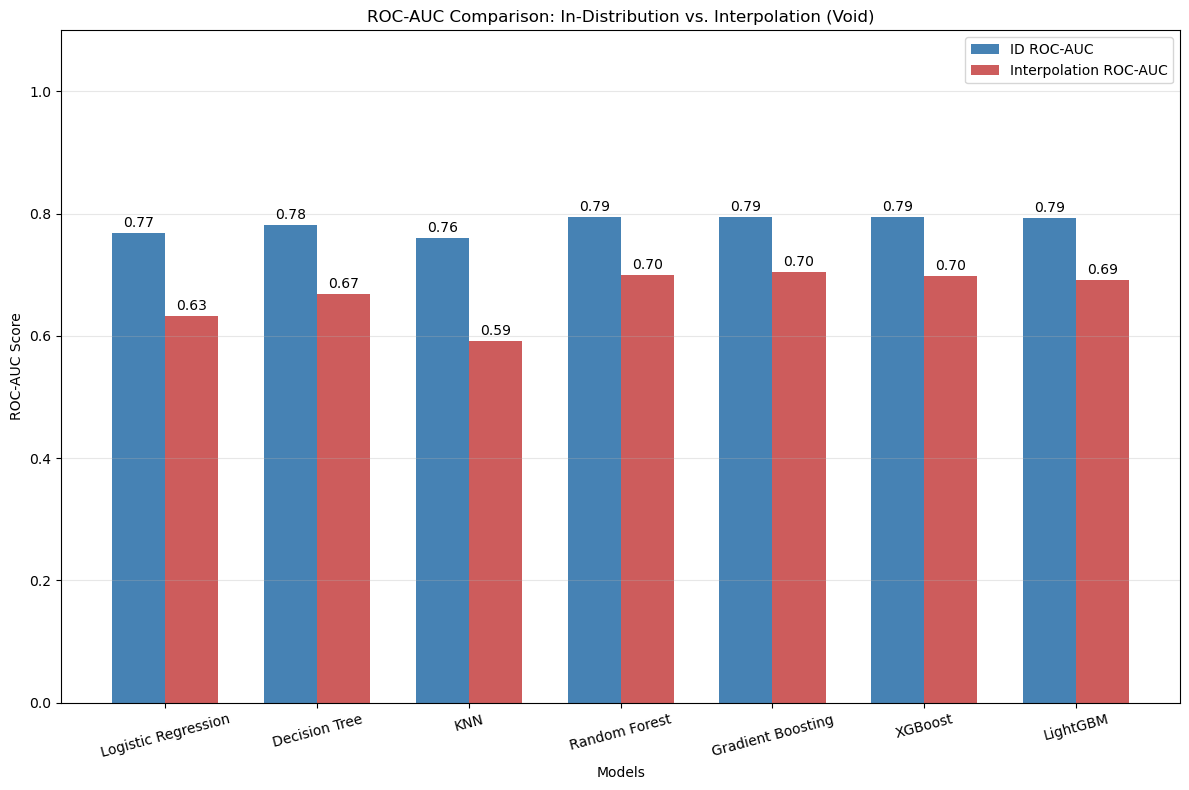

In [314]:
id_mask = np.array(region_labels == "ID")
interp_mask = np.array(region_labels == "Interpolation")

roc_results = {}

for model_name, outputs in models.items():
    y_pred, y_conf, y_prob = outputs
    y_prob = np.array(y_prob)
    
    id_auc = roc_auc_score(y_test[id_mask], y_prob[id_mask])
    interp_auc = roc_auc_score(y_test[interp_mask], y_prob[interp_mask])
    
    roc_results[model_name] = {"ID": id_auc, "Interpolation": interp_auc}

models_list = list(roc_results.keys())
id_scores = [roc_results[m]["ID"] for m in models_list]
interp_scores = [roc_results[m]["Interpolation"] for m in models_list]

x = np.arange(len(models_list))
width = 0.35

plt.figure(figsize=(12, 8))
bars1 = plt.bar(x - width/2, id_scores, width, label="ID ROC-AUC", color='steelblue')
bars2 = plt.bar(x + width/2, interp_scores, width, label="Interpolation ROC-AUC", color='indianred')

plt.xticks(x, models_list, rotation=15)
plt.ylabel("ROC-AUC Score")
plt.xlabel("Models")
plt.title("ROC-AUC Comparison: In-Distribution vs. Interpolation (Void)")
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.2f}", ha='center', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.2f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

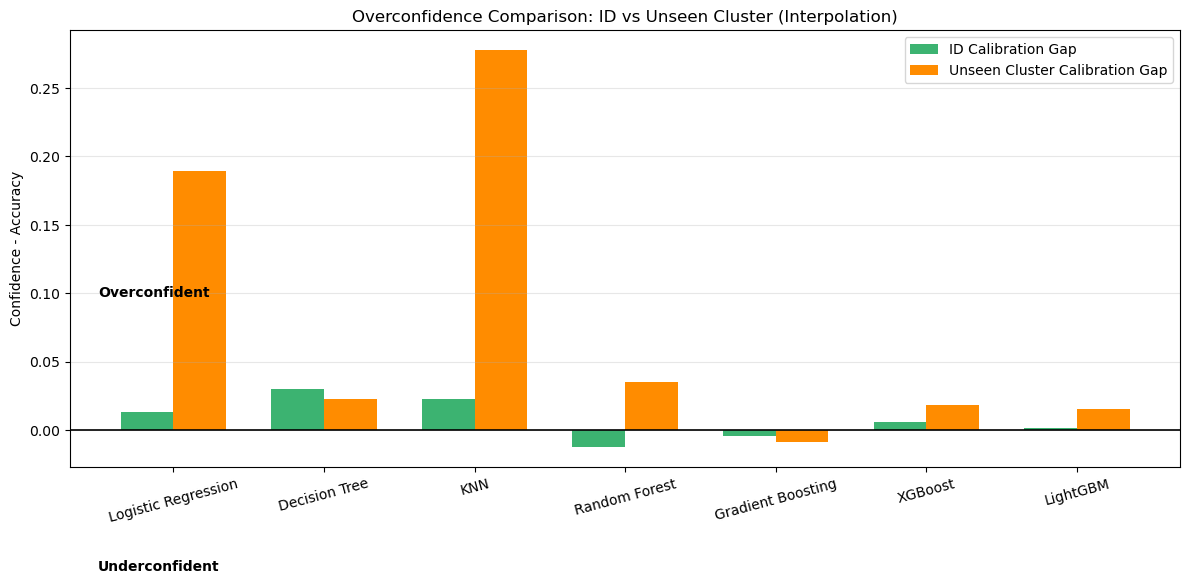

In [315]:
models_list = list(results.keys())
gap_id = []
gap_interp = []

for m in models_list:
    # Calculation: Confidence - Accuracy
    # Positive = Overconfident | Negative = Underconfident
    id_gap = results[m]["ID"]["mean_confidence"] - results[m]["ID"]["accuracy"]
    interp_gap = results[m]["Interpolation"]["mean_confidence"] - results[m]["Interpolation"]["accuracy"]
    
    gap_id.append(id_gap)
    gap_interp.append(interp_gap)

x = np.arange(len(models_list))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, gap_id, width, label="ID Calibration Gap", color='mediumseagreen')
plt.bar(x + width/2, gap_interp, width, label="Unseen Cluster Calibration Gap", color='darkorange')

plt.axhline(0, color='black', linewidth=1.2, linestyle='-')
plt.xticks(x, models_list, rotation=15)
plt.ylabel("Confidence - Accuracy")
plt.title("Overconfidence Comparison: ID vs Unseen Cluster (Interpolation)")

# Add annotations to explain the zones
plt.text(-0.5, 0.1, "Overconfident", fontsize=10, fontweight='bold', verticalalignment='center')
plt.text(-0.5, -0.1, "Underconfident", fontsize=10, fontweight='bold', verticalalignment='center')

plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()